# Regressão 01 - tarefa 01

### 1. Explorando a base de gorjetas

a. Na aula fizemos uma regressão de ```tip``` explicada por ```net_bill```. Carregue os pacotes e a base, crie as variáveis necessárias como na aula, e reproduza esta regressão.

b. Reproduza também o gráfico de dispersão dessas duas variáveis.

In [3]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

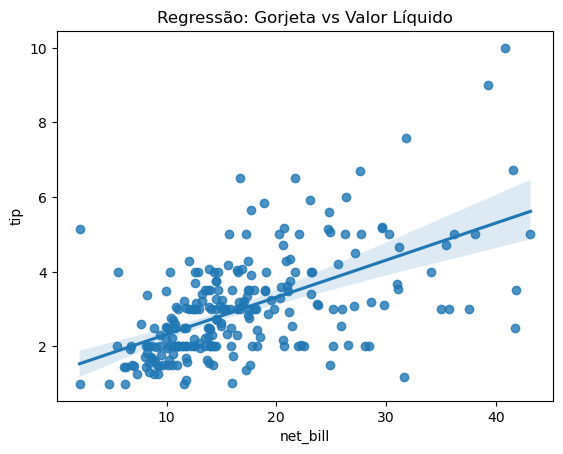

In [4]:
# Carregando os dados
tips = sns.load_dataset("tips")
tips['net_bill'] = tips['total_bill'] - tips['tip']

# Ajustando o modelo
reg1 = smf.ols('tip ~ net_bill', data=tips).fit()

# Gráfico de dispersão com linha de regressão
sns.regplot(y='tip', x='net_bill', data=tips)
plt.title('Regressão: Gorjeta vs Valor Líquido')
plt.show()

### 2. Mudança de perspectiva

Agora ajuste um modelo de regressão de ```tip_pct``` por ```net_bill```. Construa o gráfico de dispersão correspondente.

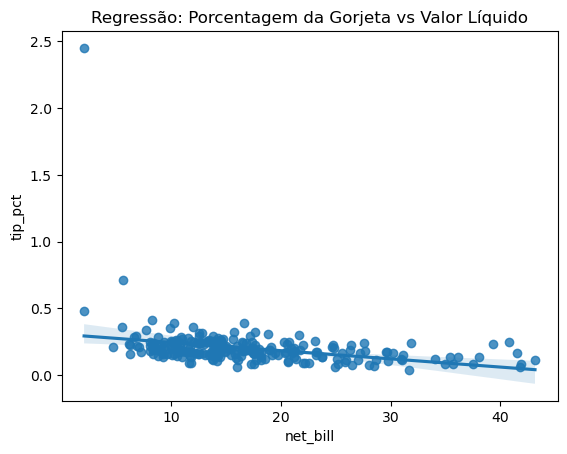

In [5]:
tips['tip_pct'] = tips['tip'] / tips['net_bill']

# Ajustando o segundo modelo
reg2 = smf.ols('tip_pct ~ net_bill', data=tips).fit()

# Gráfico de dispersão
sns.regplot(y='tip_pct', x='net_bill', data=tips)
plt.title('Regressão: Porcentagem da Gorjeta vs Valor Líquido')
plt.show()

### 3. Comente

Compare os dois gráficos e comente (de forma objetiva e suscinta) a relação entre eles e a diferença do ajuste. Podemos comparar diretamente os $R^2$s?

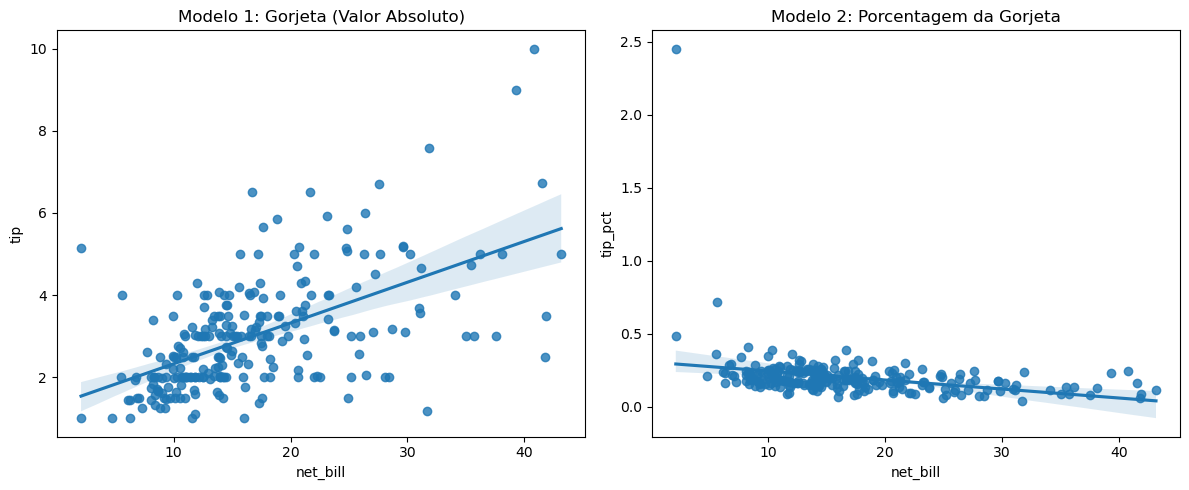

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x='net_bill', y='tip', data=tips, ax=ax[0])
ax[0].set_title('Modelo 1: Gorjeta (Valor Absoluto)')

sns.regplot(x='net_bill', y='tip_pct', data=tips, ax=ax[1])
ax[1].set_title('Modelo 2: Porcentagem da Gorjeta')

plt.tight_layout()
plt.show()

### 4. Ajuste do modelo em outra escala

Com o modelo no item 3, obtenha a preditiva do valor da gorjeta:
  1. obtenha o valor predito ```pred``` para ```tip_pct``` (dica, veja o atributo ```reg.fittedvalues```)
  2. obtenha o valor predito para ```tip``` como ```tip_pct * net_bill```
  3. calcule o $R^2$ do modelo para ```tip```
  4. compare esse $R^2$ com o do item 1

In [7]:
tips['pred_pct'] = reg2.fittedvalues

tips['pred_tip_from_pct'] = tips['pred_pct'] * tips['net_bill']

from sklearn.metrics import r2_score

r2_modelo_2_em_valor = r2_score(tips['tip'], tips['pred_tip_from_pct'])

r2_modelo_1 = reg1.rsquared

print(f"R² do Modelo 1 (Direto): {r2_modelo_1:.4f}")
print(f"R² do Modelo 2 (Convertido): {r2_modelo_2_em_valor:.4f}")

R² do Modelo 1 (Direto): 0.3325
R² do Modelo 2 (Convertido): 0.1089
